<a href="https://colab.research.google.com/github/vaishnaviikommidi007/MLProject/blob/main/MLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv('/content/drive/MyDrive/ Rossmann_Sales/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ Rossmann_Sales/test.csv')
store = pd.read_csv('/content/drive/MyDrive/ Rossmann_Sales/store.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Rossmann_Sales/train.csv'

### File Not Found Error

The `FileNotFoundError` indicates that `pandas` could not find the specified CSV files (`train.csv`, `test.csv`, `store.csv`) at the path `/content/drive/MyDrive/Rossmann_Sales/`.

This can happen if:
1. The files are not actually in that specific folder in your Google Drive.
2. There's a typo in the path or filename.

To resolve this, you need to verify the exact location of your files in Google Drive. You can use the `!ls` command to list the contents of directories within your mounted Drive.

In [5]:
# Use `!ls` to explore your Google Drive contents and find the correct path to your Rossmann_Sales folder.
# For example, to list the contents of your MyDrive:
!ls /content/drive/MyDrive

# If your files are directly in 'Rossmann_Sales' under MyDrive, you can list its contents:
# !ls /content/drive/MyDrive/Rossmann_Sales

# Once you find the correct path, update the `pd.read_csv` calls in the cell above (Ij77w0W9hMHD).

 1601-24-737-013
'160124737013 (1).gdoc'
'160124737013 (2).gdoc'
 160124737013.gdoc
 160124737013.pdf
 160124737013Week2.pdf
 2-4
'Colab Notebooks'
'Cursors and triggers.gdoc'
 DBMS
 DBMS_002.pdf
 DOC-20241121-WA0009..pdf
 functions.gdoc
'ibm (1).jpg'
 ibm.jpg
 IMG-20251224-WA0004.pdf
 IMG-20260702-WA0024.jpg
'Resume (3) (1).pdf'
'Resume_Vaishnavi (2).pdf'
'Resume_Vaishnavi (4).pdf'
 resuume3.jpg
 Retail_Demand_Forecasting
 RoadMap.pdf
 RoadMap.png
' Rossmann_Sales'
'Saved from Chrome'
 Screenshot_20250205_172226_Photos.jpg
 Screenshot_20250821_125751_Chrome.jpg
 Screenshot_20260805_115106_Chrome.jpg
 Snapchat-1686638722.jpg
'SQL Notes for Flipkart Screening.gsheet'
'Team Deeploop .pdf'
'Team Deeploop.pdf'
 Untitled1.ipynb
'VAISHNAVI DOUCUMENTS'
 vaishnaviresume.jpg
'Vaishnavi Resume.pdf'
'Varun Documents'
'vnrhacthon (1).jpg'
 vnrhacthon.jpg
'Volunteers Recruitment Drive SUDHEE’26 HRC-CBIT .gform'
'WEEK 3.pdf'
'WhatsApp Image 2026-01-06 at 1.48.00 PM.jpeg'


In [6]:
import os

path = '/content/drive/MyDrive/ Rossmann_Sales'

os.listdir(path)

['sample_submission.csv', 'train.csv', 'test.csv', 'store.csv']

In [7]:
os.listdir('/content/drive/MyDrive/ Rossmann_Sales')

['sample_submission.csv', 'train.csv', 'test.csv', 'store.csv']

In [8]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/ Rossmann_Sales/'

train = pd.read_csv(path + 'train.csv')
test = pd.read_csv(path + 'test.csv')
store = pd.read_csv(path + 'store.csv')

/tmp/ipykernel_3128/1390834232.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(path + 'train.csv')


In [9]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [10]:
train.head()
test.head()
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
test.head()


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [12]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [13]:
store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [15]:
print("Total rows:", len(store))
print("Unique stores:", store['Store'].nunique())
store['Store'].duplicated().sum()

Total rows: 1115
Unique stores: 1115


np.int64(0)

In [16]:
train_merged = train.merge(
    store,
    on='Store',
    how='left'
)

In [17]:
print("Before merge:", train.shape)
print("After merge :", train_merged.shape)

Before merge: (1017209, 9)
After merge : (1017209, 18)


In [18]:
train_merged.shape


(1017209, 18)

In [19]:
train_merged.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [20]:
train_merged.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [21]:
print(train_merged.shape)

print(train_merged.isnull().sum())

print("Duplicates:", train_merged.duplicated().sum())

print(train_merged['Sales'].describe())

print(train_merged['Open'].value_counts())

(1017209, 18)
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64
Duplicates: 0
count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64
Open
1    844392
0    172817
Name: count, dtype: int64


In [22]:
train_merged['CompetitionDistance'].median()

2330.0

In [23]:
train_merged.groupby('Open')['Sales'].mean()

,Sales
Open,
0,0.000000
1,6955.514291


In [24]:
train_merged.groupby('Promo')['Sales'].mean()

,Sales
Promo,
0,4406.050805
1,7991.152046


In [26]:
train_merged.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)


,Sales
StoreType,
b,10058.837334
a,5738.179710
c,5723.629246
d,5641.819243


In [27]:
train_merged.groupby('DayOfWeek')['Sales'].mean().sort_values(ascending=False)

,Sales
DayOfWeek,
1,7809.044510
2,7005.244467
5,6723.274305
3,6555.884138
4,6247.575913
6,5847.562599
7,204.183189


In [28]:
train_merged[train_merged['Open'] == 1].groupby('DayOfWeek')['Sales'].mean()

,Sales
DayOfWeek,
1,8216.073074
2,7088.113656
3,6728.122978
4,6767.310159
5,7072.677012
6,5874.840238
7,8224.723908


In [29]:
train_merged.groupby('DayOfWeek')['Open'].mean()

,Open
DayOfWeek,
1,0.950459
2,0.988309
3,0.974400
4,0.923199
5,0.950598
6,0.995357
7,0.024826


In [30]:
train_merged.groupby(['Open', 'Promo'])['Sales'].mean()

Open  Promo
0     0           0.000000
      1           0.000000
1     0        5929.407603
      1        8228.281239
Name: Sales, dtype: float64

In [31]:
train_merged.groupby('StateHoliday')['Sales'].mean()

,Sales
StateHoliday,
0,5733.530624
0,5980.279717
a,290.735686
b,214.311510
c,168.733171


In [32]:
train_merged.groupby('SchoolHoliday')['Sales'].mean()

,Sales
SchoolHoliday,
0,5620.979034
1,6476.522207


In [33]:
train_merged[train_merged['Open'] == 1].groupby('StateHoliday')['Sales'].mean()

,Sales
StateHoliday,
0,6701.492117
0,6992.158856
a,8487.471182
b,9887.889655
c,9743.746479


In [34]:
train_merged['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [35]:
train_merged['StateHoliday'].dtype

dtype('O')

In [36]:
print(train_merged['StateHoliday'].value_counts(dropna=False))

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [37]:
train_merged['StateHoliday'] = train_merged['StateHoliday'].astype(str)

In [38]:
train_merged['StateHoliday'].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [39]:
train_merged['StateHoliday'].value_counts()

,count
StateHoliday,
0,986159
a,20260
b,6690
c,4100


In [40]:
train_merged['CompetitionDistance'] = train_merged['CompetitionDistance'].fillna(
    train_merged['CompetitionDistance'].median()
)

In [41]:
train_merged['CompetitionDistance'].isnull().sum()

np.int64(0)

In [42]:
train_merged.groupby('Promo2')[[
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'PromoInterval'
]].apply(lambda x: x.isnull().sum())

,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,508031,508031,508031
1,0,0,0


In [43]:
train_merged['Promo2SinceWeek'] = train_merged['Promo2SinceWeek'].fillna(0)
train_merged['Promo2SinceYear'] = train_merged['Promo2SinceYear'].fillna(0)
train_merged['PromoInterval'] = train_merged['PromoInterval'].fillna('None')

In [44]:
train_merged[['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].isnull().sum()

,0
Promo2SinceWeek,0
Promo2SinceYear,0
PromoInterval,0


In [45]:
train_merged['Year'] = train_merged['Date'].dt.year
train_merged['Month'] = train_merged['Date'].dt.month
train_merged['Day'] = train_merged['Date'].dt.day
train_merged['WeekOfYear'] = train_merged['Date'].dt.isocalendar().week.astype(int)

AttributeError: Can only use .dt accessor with datetimelike values

In [46]:
train_merged['Date'].dtype

dtype('O')

In [47]:
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

In [48]:
train_merged['Date'].dtype

dtype('<M8[ns]')

In [49]:
train_merged['Year'] = train_merged['Date'].dt.year
train_merged['Month'] = train_merged['Date'].dt.month
train_merged['Day'] = train_merged['Date'].dt.day
train_merged['WeekOfYear'] = train_merged['Date'].dt.isocalendar().week.astype(int)
train_merged['IsWeekend'] = train_merged['DayOfWeek'].isin([6, 7]).astype(int)

In [50]:
train_merged[
    ['Date', 'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfWeek', 'IsWeekend']
].head()

,Date,Year,Month,Day,WeekOfYear,DayOfWeek,IsWeekend
0,2015-07-31,2015,7,31,31,5,0
1,2015-07-31,2015,7,31,31,5,0
2,2015-07-31,2015,7,31,31,5,0
3,2015-07-31,2015,7,31,31,5,0
4,2015-07-31,2015,7,31,31,5,0


In [51]:
train_merged['Date'].dt.year

,Date
0,2015
1,2015
2,2015
3,2015
4,2015
...,...
1017204,2013
1017205,2013
1017206,2013
1017207,2013


In [52]:
train_merged[['Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend']].head()

,Year,Month,Day,WeekOfYear,IsWeekend
0,2015,7,31,31,0
1,2015,7,31,31,0
2,2015,7,31,31,0
3,2015,7,31,31,0
4,2015,7,31,31,0


In [53]:
train_merged['CompetitionOpenSinceMonth'] = train_merged[
    'CompetitionOpenSinceMonth'
].fillna(0)

train_merged['CompetitionOpenSinceYear'] = train_merged[
    'CompetitionOpenSinceYear'
].fillna(0)

In [54]:
train_merged['CompetitionOpenMonths'] = (
    (train_merged['Year'] - train_merged['CompetitionOpenSinceYear']) * 12
    + (train_merged['Month'] - train_merged['CompetitionOpenSinceMonth'])
)

In [55]:
train_merged.loc[
    train_merged['CompetitionOpenSinceYear'] == 0,
    'CompetitionOpenMonths'
] = 0

In [56]:
train_merged['CompetitionOpenMonths'].describe()

,CompetitionOpenMonths
count,1.017209e+06
mean,4.114934e+01
std,6.601545e+01
min,-3.100000e+01
25%,0.000000e+00
50%,1.600000e+01
75%,7.300000e+01
max,1.386000e+03


In [57]:
train_merged.loc[
    train_merged['CompetitionOpenMonths'] < 0,
    'CompetitionOpenMonths'
] = 0

In [58]:
train_merged['CompetitionOpenMonths'].describe()

,CompetitionOpenMonths
count,1.017209e+06
mean,4.203993e+01
std,6.534447e+01
min,0.000000e+00
25%,0.000000e+00
50%,1.600000e+01
75%,7.300000e+01
max,1.386000e+03


In [59]:
train_merged.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [60]:
train_merged.shape

(1017209, 24)

In [61]:
train_merged.dtypes

,0
Store,int64
DayOfWeek,int64
Date,datetime64[ns]
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object


In [62]:
train_merged.groupby('Year')['Sales'].mean()

,Sales
Year,
2013,5658.533675
2014,5833.290704
2015,5878.245380


In [63]:
train_merged.groupby('Month')['Sales'].mean()

,Sales
Month,
1,5465.395529
2,5645.253150
3,5784.578871
4,5738.866916
5,5489.639973
6,5760.964375
7,6064.915711
8,5693.016554
9,5570.246033


In [64]:
monthly_sales = train_merged.groupby(
    ['Year', 'Month']
)['Sales'].mean()

monthly_sales

Year  Month
2013  1        5211.555578
      2        5494.371397
      3        5820.349168
      4        5483.749836
      5        5364.127383
      6        5402.162960
      7        6042.062260
      8        5729.574049
      9        5322.988430
      10       5429.258788
      11       5864.601614
      12       6703.618140
2014  1        5431.875799
      2        5731.091512
      3        5584.257312
      4        5815.993333
      5        5632.670534
      6        5681.526188
      7        5999.403381
      8        5649.421252
      9        5865.104029
      10       5665.564878
      11       6179.249661
      12       6973.282456
2015  1        5752.747866
      2        5710.296541
      3        5949.130132
      4        5916.857578
      5        5472.122002
      6        6199.203976
      7        6142.705511
Name: Sales, dtype: float64

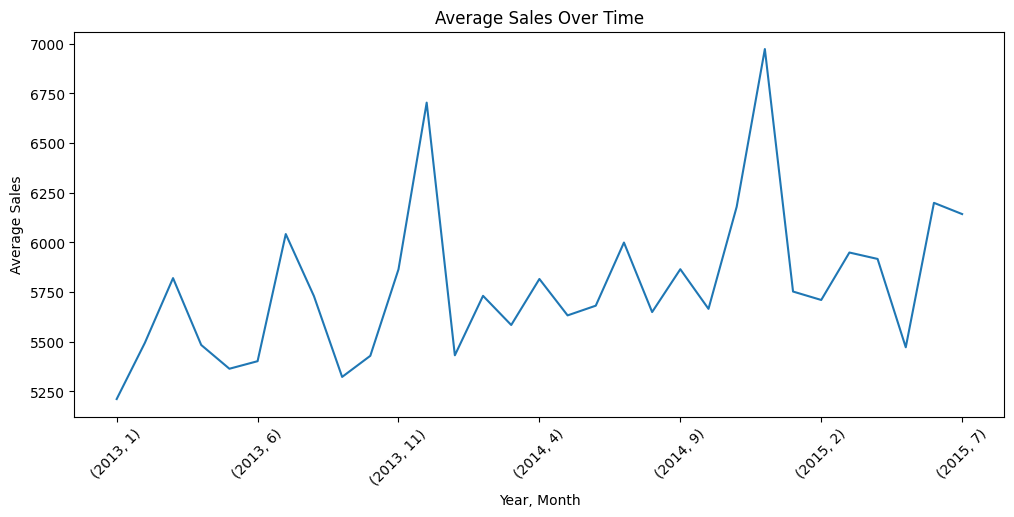

In [65]:
import matplotlib.pyplot as plt

monthly_sales = train_merged.groupby(
    ['Year', 'Month']
)['Sales'].mean()

monthly_sales.plot(figsize=(12, 5))

plt.xlabel('Year, Month')
plt.ylabel('Average Sales')
plt.title('Average Sales Over Time')
plt.xticks(rotation=45)
plt.show()

In [66]:
print("Yearly:")
print(train_merged.groupby('Year')['Sales'].mean())

print("\nMonthly:")
print(train_merged.groupby('Month')['Sales'].mean())

print("\nYear + Month:")
print(train_merged.groupby(['Year', 'Month'])['Sales'].mean())

Yearly:
Year
2013    5658.533675
2014    5833.290704
2015    5878.245380
Name: Sales, dtype: float64

Monthly:
Month
1     5465.395529
2     5645.253150
3     5784.578871
4     5738.866916
5     5489.639973
6     5760.964375
7     6064.915711
8     5693.016554
9     5570.246033
10    5537.037419
11    6008.111821
12    6826.611377
Name: Sales, dtype: float64

Year + Month:
Year  Month
2013  1        5211.555578
      2        5494.371397
      3        5820.349168
      4        5483.749836
      5        5364.127383
      6        5402.162960
      7        6042.062260
      8        5729.574049
      9        5322.988430
      10       5429.258788
      11       5864.601614
      12       6703.618140
2014  1        5431.875799
      2        5731.091512
      3        5584.257312
      4        5815.993333
      5        5632.670534
      6        5681.526188
      7        5999.403381
      8        5649.421252
      9        5865.104029
      10       5665.564878
      11       617

In [67]:
train_merged.select_dtypes(include='object').columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

In [68]:
categorical_cols = [
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

In [69]:
train_encoded = pd.get_dummies(
    train_merged,
    columns=categorical_cols,
    drop_first=True
)

In [70]:
train_encoded.shape

(1017209, 31)

In [71]:
train_encoded.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_None
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,...,False,False,False,True,False,False,False,False,False,True
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,...,False,False,False,False,False,False,False,True,False,False
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,...,False,False,False,False,False,False,False,True,False,False
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,...,False,False,False,True,False,False,True,False,False,True
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,...,False,False,False,False,False,False,False,False,False,True


In [72]:
print(train_encoded.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None']


In [73]:
drop_columns = [
    'Sales',
    'Customers',   # Not available in test.csv
    'Date'
]

X = train_encoded.drop(columns=drop_columns)
y = train_encoded['Sales']

In [74]:
print(X.shape)
print(y.shape)

(1017209, 28)
(1017209,)


In [75]:
train_encoded = train_encoded.sort_values('Date')

train_data = train_encoded[train_encoded['Date'] < '2015-06-15']
valid_data = train_encoded[train_encoded['Date'] >= '2015-06-15']

In [76]:
X_train = train_data.drop(columns=drop_columns)
y_train = train_data['Sales']

X_valid = valid_data.drop(columns=drop_columns)
y_valid = valid_data['Sales']

In [77]:
print(X_train.shape)
print(X_valid.shape)

(964804, 28)
(52405, 28)


In [78]:
print(train_data['Date'].min(), train_data['Date'].max())
print(valid_data['Date'].min(), valid_data['Date'].max())

2013-01-01 00:00:00 2015-06-14 00:00:00
2015-06-15 00:00:00 2015-07-31 00:00:00


In [79]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [80]:
y_pred = lr.predict(X_valid)

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 1781.2349944734747
RMSE: 2500.169061975722


In [82]:
def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            ((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2
        )
    )

print("RMSPE:", rmspe(y_valid, y_pred))

RMSPE: 0.4839279396258329


In [83]:
model_results = []

model_results.append({
    "Model": "Linear Regression",
    "RMSPE": rmspe(y_valid, y_pred),
    "RMSE": rmse,
    "MAE": mae
})

import pandas as pd

results = pd.DataFrame(model_results)
results

,Model,RMSPE,RMSE,MAE
0,Linear Regression,0.483928,2500.169062,1781.234994


In [92]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=1,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1, random_state=42)

In [93]:
dt_pred = dt.predict(X_valid)

In [94]:
mae_dt = mean_absolute_error(y_valid, dt_pred)
rmse_dt = np.sqrt(mean_squared_error(y_valid, dt_pred))

print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("RMSPE:", rmspe(y_valid, dt_pred))

MAE : 1980.3023754938013
RMSE: 2895.6064337704197
RMSPE: 0.5568078982897354


In [90]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            ((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2
        )
    )

max_depths = range(1, 21) # Test max_depth from 1 to 20
rmspe_scores = []

for depth in max_depths:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train, y_train)
    dt_pred = dt_model.predict(X_valid)
    score = rmspe(y_valid, dt_pred)
    rmspe_scores.append(score)

# Find the optimal max_depth
best_depth_index = np.argmin(rmspe_scores)
best_max_depth = max_depths[best_depth_index]
best_rmspe = rmspe_scores[best_depth_index]

print(f"Optimal max_depth: {best_max_depth}")
print(f"Best RMSPE at optimal depth: {best_rmspe}")

Optimal max_depth: 20
Best RMSPE at optimal depth: 0.22072955593108862


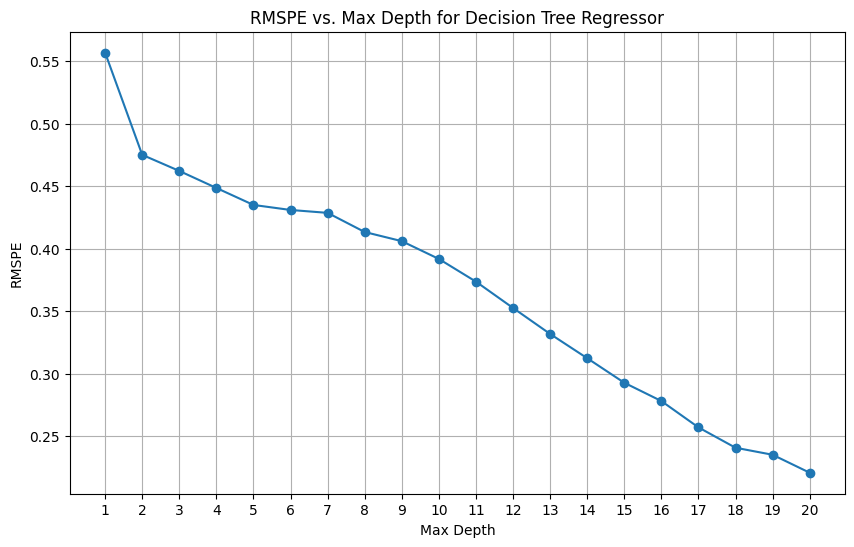

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(max_depths, rmspe_scores, marker='o')
plt.title('RMSPE vs. Max Depth for Decision Tree Regressor')
plt.xlabel('Max Depth')
plt.ylabel('RMSPE')
plt.xticks(max_depths)
plt.grid(True)
plt.show()